# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [6]:
import pandas as pd
import sklearn
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv"

### Step 1. Load the data

In [7]:
# pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv").head()
df = pd.read_csv(url)
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [8]:
X = df[['Hours_Studied']]
y = df['Marks']

### Step 2.b print the type of each

In [9]:
X.dtypes

Hours_Studied    float64
dtype: object

In [11]:
y.dtypes

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [ ]:
#regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [13]:
y.shape

(100,)

In [14]:
X.shape

(100, 1)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [15]:
y.describe()

count    100.000000
mean      46.360200
std       14.284805
min       20.190000
25%       33.675000
50%       47.485000
75%       57.377500
max       73.260000
Name: Marks, dtype: float64

In [16]:
X.describe()

,Hours_Studied
count,100.000000
mean,5.376300
std,2.593013
min,1.050000
25%,3.175000
50%,5.565000
75%,7.255000
max,9.870000


### Step 5. Plot the feature vs the target

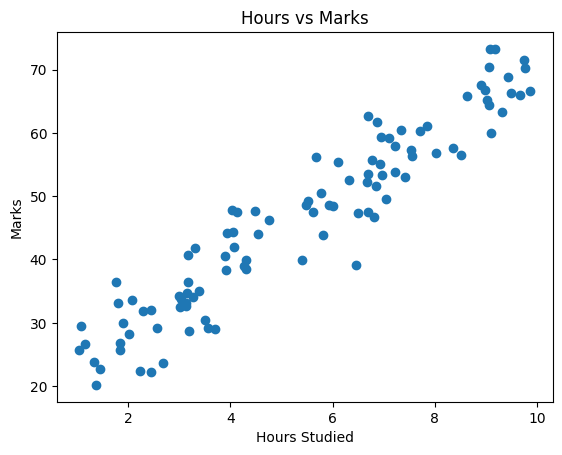

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [9]:
#Increasing relationship

### Step 7. Initialize a `LinearRegression` model

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

### Step 9.a Train the model on the training set

In [24]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [25]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 5.164438413499557
Intercept: 18.538578512317272


### Step 9.c how much marks do we get per 1 hour of study?

In [26]:
model.coef_[0]

np.float64(5.164438413499557)

### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [27]:
model.coef_[0] * (10/60)

np.float64(0.8607397355832594)

### Step 9.e if one doesn't study at all, how much marks do they get?

In [28]:
model.intercept_

np.float64(18.538578512317272)

### Step 10. Evaluate the model on the test set

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 14.731128407667569
R2 Score: 0.9258085525213728


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [30]:
sample_X = X_test[:3]
sample_y = y_test[:3]

predictions = model.predict(sample_X)

print("Predictions:", predictions)
print("Actual:", sample_y.values)

Predictions: [34.13518252 64.50208039 53.55347096]
Actual: [32.5  67.54 55.7 ]


### Step 12. Plot the data and the regression line

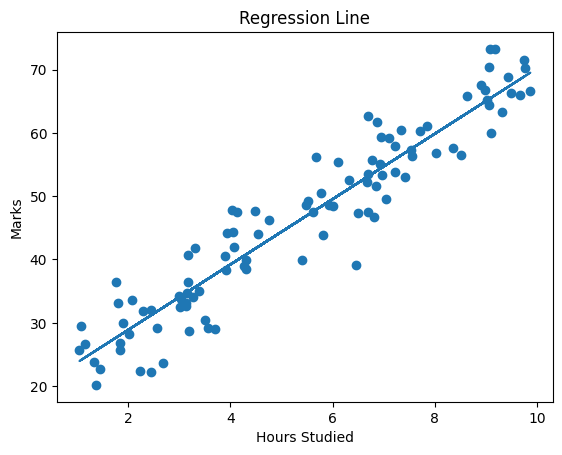

In [31]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(X, y)

# Regression line
y_line = model.predict(X)
plt.plot(X, y_line)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Regression Line")

plt.show()